<a href="https://colab.research.google.com/github/Mukhesh27/Hybrid_CNN_Transformer_model_for_ecg/blob/main/Model_loading_and_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=512, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=2, stride=2)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

In [ ]:
state_dict = torch.load("/content/drive/MyDrive/ecg_final_pap.pth", map_location=device)

In [ ]:
num_layers = len(set([k.split('.')[2] for k in state_dict.keys() if "transformer.layers" in k]))
print("Detected Transformer Layers:", num_layers)

Detected Transformer Layers: 4


In [ ]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=5, num_layers=4):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])

        self.patch_embed = PatchEmbedding(512, 256)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = self.patch_embed(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

In [ ]:
model = HybridModel(num_classes=5, num_layers=num_layers).to(device)

model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.2MB/s]


✅ Model loaded successfully


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lfig_222.png to Lfig_222.png


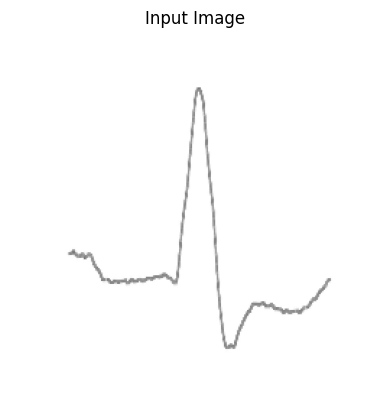

In [ ]:
image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert('RGB')

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

image = transform(image)
image = image.unsqueeze(0)
image = image.to(device)

In [ ]:
class_names = ['F', 'N', 'Q', 'S', 'V']

print(" Predicted Class:", class_names[pred_class])
print(" Confidence:", round(conf*100, 2), "%")

 Predicted Class: N
 Confidence: 99.98 %
